In [6]:
import pandahouse as ph
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [7]:
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'database': 'simulator_20260920',
    'user': 'student',
    'password': 'dpo_python_2020'
}

test = ph.read_clickhouse("SELECT 1", connection=connection)
print(test)

   1
0  1


In [8]:
query = """
SELECT 
    exp_group,
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20260920.feed_actions
WHERE toDate(time) BETWEEN '2026-08-28' AND '2026-09-03'
  AND exp_group IN (1, 2)
GROUP BY exp_group, user_id
"""

df_ab = ph.read_clickhouse(query, connection=connection)
df_ab.head()

,exp_group,user_id,likes,views,ctr
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750


In [9]:
group_1 = df_ab[df_ab.exp_group == 1]['ctr']
group_2 = df_ab[df_ab.exp_group == 2]['ctr']

print(f'Группа 1 (контроль): {len(group_1)} пользователей, средний CTR = {group_1.mean():.4f}')
print(f'Группа 2 (новый алгоритм): {len(group_2)} пользователей, средний CTR = {group_2.mean():.4f}')

Группа 1 (контроль): 10020 пользователей, средний CTR = 0.2168
Группа 2 (новый алгоритм): 9877 пользователей, средний CTR = 0.2161


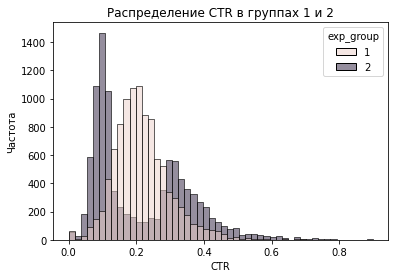

In [10]:
sns.histplot(data=df_ab, x='ctr', hue='exp_group', bins=50, kde=False, alpha=0.5)
plt.title('Распределение CTR в группах 1 и 2')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.show()

In [11]:
t_stat, p_val = stats.ttest_ind(group_1, group_2, equal_var=False)
print(f't-статистика: {t_stat:.4f}')
print(f'p-value: {p_val:.4f}')

t-статистика: 0.4051
p-value: 0.6854


In [12]:
from scipy.stats import mannwhitneyu

stat, p_val_mw = mannwhitneyu(group_1, group_2)
print(f'Статистика Манна-Уитни: {stat:.4f}')
print(f'p-value (Манн-Уитни): {p_val_mw:.4f}')

Статистика Манна-Уитни: 55189913.0000
p-value (Манн-Уитни): 0.0000


In [13]:
alpha = 5

global_ctr_1 = df_ab[df_ab.exp_group == 1]['likes'].sum() / df_ab[df_ab.exp_group == 1]['views'].sum()
global_ctr_2 = df_ab[df_ab.exp_group == 2]['likes'].sum() / df_ab[df_ab.exp_group == 2]['views'].sum()

print(f'Глобальный CTR группы 1: {global_ctr_1:.4f}')
print(f'Глобальный CTR группы 2: {global_ctr_2:.4f}')

df_ab['smoothed_ctr'] = (df_ab['likes'] + alpha * df_ab['exp_group'].map({1: global_ctr_1, 2: global_ctr_2})) / (df_ab['views'] + alpha)

group_1_smooth = df_ab[df_ab.exp_group == 1]['smoothed_ctr']
group_2_smooth = df_ab[df_ab.exp_group == 2]['smoothed_ctr']

t_stat_s, p_val_s = stats.ttest_ind(group_1_smooth, group_2_smooth, equal_var=False)
print(f't-статистика (сглаженный): {t_stat_s:.4f}')
print(f'p-value (сглаженный): {p_val_s:.4f}')

Глобальный CTR группы 1: 0.2096
Глобальный CTR группы 2: 0.2003
t-статистика (сглаженный): 1.9460
p-value (сглаженный): 0.0517


In [14]:
import hashlib

query = """
SELECT 
    exp_group,
    bucket,
    sum(likes)/sum(views) as bucket_ctr,
    quantileExact(0.9)(ctr) as ctr9
FROM (
    SELECT 
        exp_group,
        cityHash64(user_id)%50 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM simulator_20260920.feed_actions
    WHERE toDate(time) BETWEEN '2026-08-28' AND '2026-09-03'
      AND exp_group IN (1, 2)
    GROUP BY exp_group, bucket, user_id
)
GROUP BY exp_group, bucket
"""

df_bucket = ph.read_clickhouse(query, connection=connection)

t_stat_b, p_val_b = stats.ttest_ind(
    df_bucket[df_bucket.exp_group == 1]['bucket_ctr'],
    df_bucket[df_bucket.exp_group == 2]['bucket_ctr'],
    equal_var=False
)
print(f't-статистика (бакеты): {t_stat_b:.4f}')
print(f'p-value (бакеты): {p_val_b:.4f}')

t-статистика (бакеты): 6.3417
p-value (бакеты): 0.0000


In [15]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):
    poisson_bootstraps1 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes1))
    ).astype(np.int64)

    poisson_bootstraps2 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes2))
    ).astype(np.int64)

    globalCTR1 = (poisson_bootstraps1 * likes1).sum(axis=1) / (poisson_bootstraps1 * views1).sum(axis=1)
    globalCTR2 = (poisson_bootstraps2 * likes2).sum(axis=1) / (poisson_bootstraps2 * views2).sum(axis=1)

    return globalCTR1, globalCTR2

likes1 = df_ab[df_ab.exp_group == 1]['likes'].to_numpy()
views1 = df_ab[df_ab.exp_group == 1]['views'].to_numpy()
likes2 = df_ab[df_ab.exp_group == 2]['likes'].to_numpy()
views2 = df_ab[df_ab.exp_group == 2]['views'].to_numpy()

ctr1_boot, ctr2_boot = bootstrap(likes1, views1, likes2, views2)

diff = ctr2_boot - ctr1_boot
p_val_boot = (diff <= 0).mean()
print(f'Средняя разница CTR: {diff.mean():.6f}')
print(f'p-value (бутстреп): {p_val_boot:.4f}')

Средняя разница CTR: -0.009318
p-value (бутстреп): 1.0000
